In [98]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [99]:

dataset_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset"

for item in os.listdir(dataset_path):
    print(item)

.DS_Store
train
val


In [100]:


train_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset/train"

for item in os.listdir(train_path):
    print(item)

fractured
not fractured


In [101]:


fractured_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset/train/fractured"

not_fractured_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset/train/not fractured"

print("Fractured Images:", len(os.listdir(fractured_path)))

print("Non-Fractured Images:", len(os.listdir(not_fractured_path)))

Fractured Images: 4480
Non-Fractured Images: 4383


Image Shape: (2056, 3138)


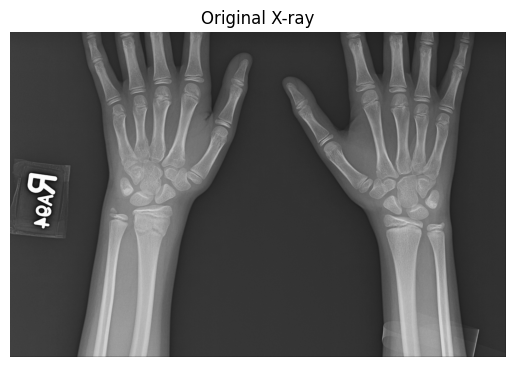

In [102]:


fractured_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset/train/fractured"

image_name = os.listdir(fractured_path)[0]

image_path = os.path.join(fractured_path, image_name)

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print("Image Shape:", img.shape)

plt.imshow(img, cmap="gray")
plt.title("Original X-ray")
plt.axis("off")
plt.show()

Resized Shape: (128, 128)


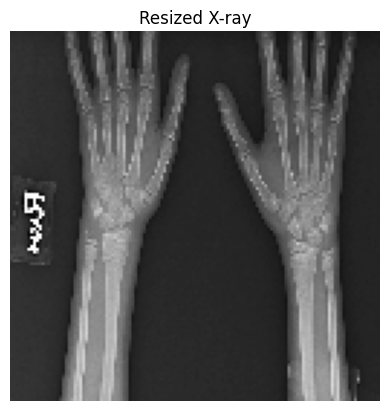

In [103]:
img = cv2.resize(img, (128,128))

print("Resized Shape:", img.shape)

plt.imshow(img, cmap='gray')
plt.title("Resized X-ray")
plt.axis('off')
plt.show()

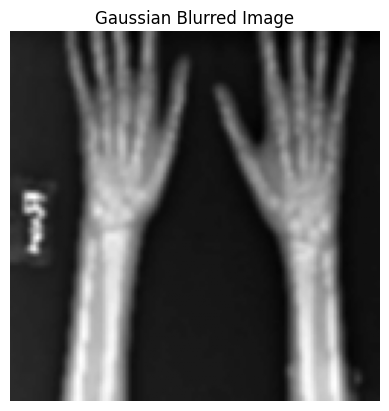

In [104]:
# Gaussian Blur

blurred = cv2.GaussianBlur(img, (5,5), 0)

plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis('off')
plt.show()

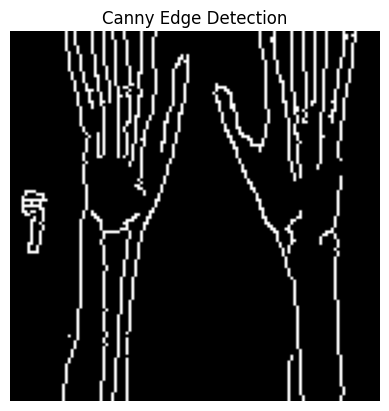

In [105]:
#Canny Edge Detection

edges = cv2.Canny(blurred, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

In [106]:
!pip install scikit-image


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [107]:
import skimage

print(skimage.__version__)

0.26.0


In [108]:
#Feature Extraction

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128,128))

blurred = cv2.GaussianBlur(img, (5,5), 0)

edges = cv2.Canny(blurred, 50, 150)

features = edges.flatten()

In [75]:
# now start ml Next Phase: Create Dataset for ML

# Now we'll process all images automatically.

In [112]:
#create dataset 
X = []
y = []

In [113]:
"""
Process Fractured Images

To save time, let's initially use only 1000 images from each clas

"""

"\nProcess Fractured Images\n\nTo save time, let's initially use only 1000 images from each clas\n\n"

In [114]:
fractured_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset/train/fractured"

fractured_images = os.listdir(fractured_path)[:1000]

for image in fractured_images:

    image_path = os.path.join(
        fractured_path,
        image
    )

    try:
        features = extract_features(
            image_path
        )

        X.append(features)
        y.append(1)

    except:
        pass

print("Fractured Done")

Fractured Done


In [115]:
# Process Non-Fractured Images

nonfractured_path = "/Users/surinderpalsingh/Desktop/bonefracture/Bone_Fracture_Dataset/train/not fractured"

nonfractured_images = os.listdir(nonfractured_path)[:1000]

for image in nonfractured_images:

    image_path = os.path.join(
        nonfractured_path,
        image
    )

    try:
        features = extract_features(
            image_path
        )

        X.append(features)
        y.append(0)

    except:
        pass

print("Non-Fractured Done")

Non-Fractured Done


In [116]:
#Convert to NumPy
X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (2000, 8100)
Y Shape: (2000,)


In [117]:
""" This means:

2000 X-ray images processed
Each image represented by 8100 HOG features
Labels:
1 = Fractured
0 = Non-Fractured

Now let's train the classifier."""

" This means:\n\n2000 X-ray images processed\nEach image represented by 8100 HOG features\nLabels:\n1 = Fractured\n0 = Non-Fractured\n\nNow let's train the classifier."

In [118]:
# Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (1600, 8100)
Testing Samples: (400, 8100)


In [119]:
# Train SVM
from sklearn.svm import SVC

model = SVC(
    kernel='linear',
    random_state=42
)

model.fit(X_train, y_train)

print("Training Complete")

Training Complete


In [120]:
# prediction 
y_pred = model.predict(X_test)

In [121]:
# accuracy 

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy * 100)

Accuracy: 80.25


In [122]:
# confusion mtrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[161  39]
 [ 40 160]]


In [123]:
# clssifiction report 

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       200
           1       0.80      0.80      0.80       200

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



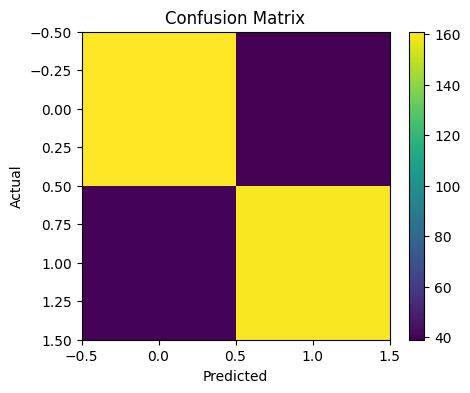

In [124]:
# Visualize Confusion Matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()